<ipython-input-5-79c8e2395bb7>:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Revenue..Millions.'].fillna(df_clean['Revenue..Millions.'].median(), inplace=True)


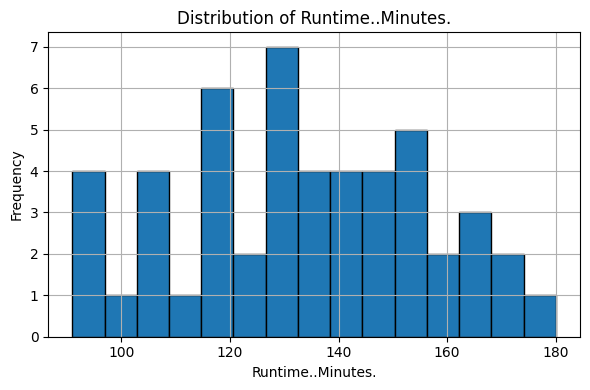

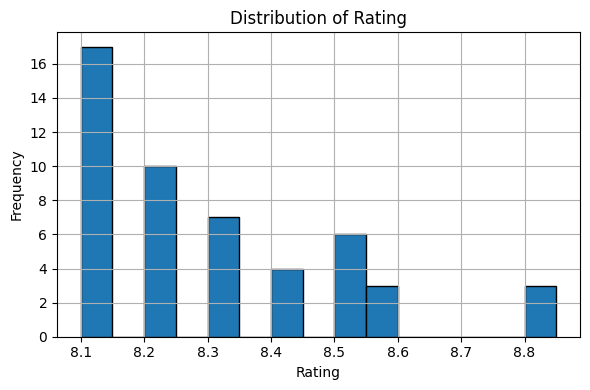

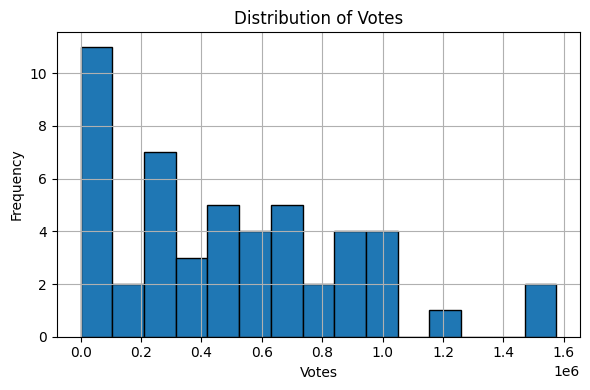

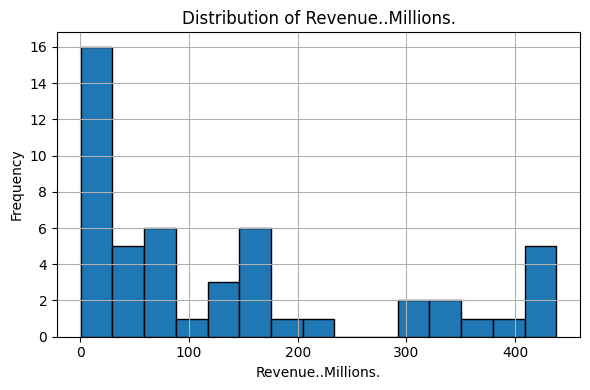

  Principal Component  Explained Variance Ratio  Cumulative Variance
0                 PC1                  0.445875             0.445875
1                 PC2                  0.298399             0.744274
2                 PC3                  0.193949             0.938223
3                 PC4                  0.061777             1.000000


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("IMDB-Movies.csv")

# Drop unnecessary columns
df_clean = df.drop(columns=["Unnamed: 0", "Title", "Genre", "Description", "Director", "Actors", "Year"])

# Fill missing values in 'Revenue..Millions.' using median
df_clean['Revenue..Millions.'].fillna(df_clean['Revenue..Millions.'].median(), inplace=True)

# Function to cap outliers using IQR
def handle_outliers(column):
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[column] = np.where(df_clean[column] < lower, lower, df_clean[column])
    df_clean[column] = np.where(df_clean[column] > upper, upper, df_clean[column])

# Apply outlier handling
for col in df_clean.columns:
    handle_outliers(col)

# EDA: Plot distributions
for col in df_clean.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df_clean[col], bins=15, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

# Apply PCA
pca = PCA()
pca_data = pca.fit_transform(scaled_data)

# Explained variance DataFrame
explained_variance = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})

print(explained_variance)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

# Add KMeans cluster labels to DataFrame
df_kmeans = df_clean.copy()
df_kmeans['KMeans_Cluster'] = kmeans_labels

# Hierarchical Clustering
linkage_matrix = linkage(scaled_data, method='ward')
hierarchical_labels = fcluster(linkage_matrix, 3, criterion='maxclust')
df_kmeans['Hierarchical_Cluster'] = hierarchical_labels

# Cluster Centers (KMeans)
kmeans_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df_clean.columns
)
print("\nKMeans Cluster Centers:\n", kmeans_centers)

# Average metrics by cluster
df_kmeans_summary = df_kmeans.groupby(['KMeans_Cluster', 'Hierarchical_Cluster']).mean(numeric_only=True)
print("\nCluster Averages:\n", df_kmeans_summary)





KMeans Cluster Centers:
    Runtime..Minutes.    Rating         Votes  Revenue..Millions.
0         150.052632  8.263158  5.822862e+05          145.040921
1         117.703704  8.255556  3.299649e+05          101.394074
2         158.250000  8.687500  1.355190e+06          338.984375

Cluster Averages:
                                      Runtime..Minutes.    Rating  \
KMeans_Cluster Hierarchical_Cluster                                
0              1                            154.200000  8.270000   
               2                            132.500000  8.100000   
               3                            155.800000  8.380000   
1              1                            121.727273  8.254545   
               2                            100.000000  8.260000   
2              3                            158.250000  8.687500   

                                            Votes  Revenue..Millions.  
KMeans_Cluster Hierarchical_Cluster                                    
0    

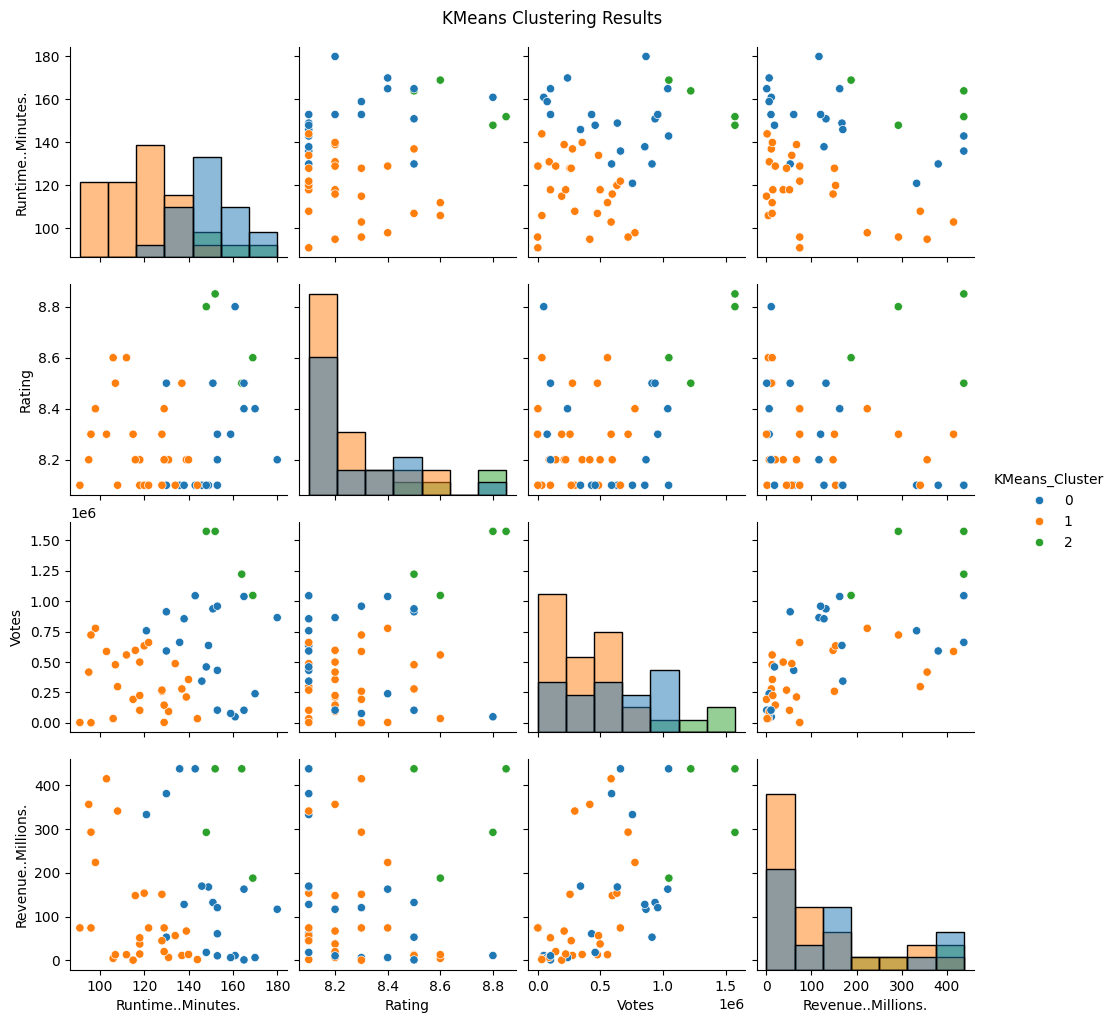

In [7]:
# Pairplot of KMeans clusters
plot_data = df_kmeans[df_clean.columns.tolist() + ['KMeans_Cluster']]
sns.pairplot(plot_data, hue="KMeans_Cluster", palette="tab10", diag_kind='hist')
plt.suptitle("KMeans Clustering Results", y=1.02)
plt.show()

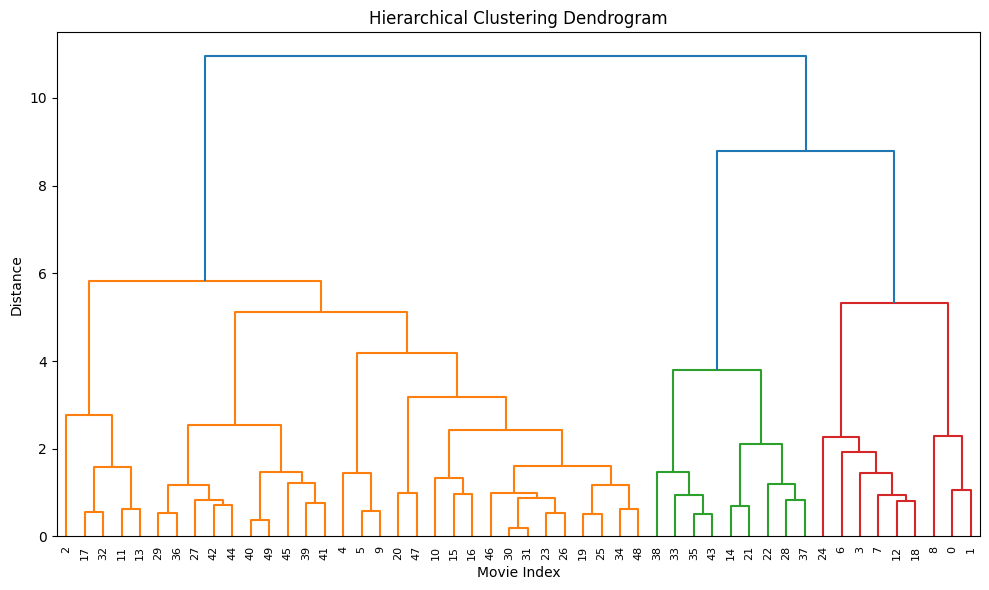

In [8]:
# Dendrogram for Hierarchical Clustering
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=df.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Movie Index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()
